# SVM NAIVE BAYES

#Theory

1. What is a Support Vector Machine (SVM)?

- SVM is a supervised machine learning algorithm used for classification and regression. It finds the optimal hyperplane that separates data points of different classes with the maximum margin.

2. Difference between Hard Margin and Soft Margin SVM

- Hard Margin SVM: No misclassification allowed, works only for perfectly separable data.

- Soft Margin SVM: Allows some misclassification using a penalty parameter (C), works for real-world noisy data

3. What is the mathematical intuition behind SVM?
- SVM tries to maximize the margin between two classes while minimizing classification error. It solves an optimization problem:
- Maximize margin
- Minimize error using constraints

4. What is the role of Lagrange Multipliers in SVM?
- They help convert constrained optimization into an unconstrained problem.
They allow SVM to focus only on important points (support vectors).

5. What are Support Vectors?

- These are the data points closest to the decision boundary.
They directly influence the position of the hyperplane.

6. What is a Support Vector Classifier (SVC)?

- SVC is the classification version of SVM used to separate classes.

7. What is a Support Vector Regressor (SVR)?

- SVR is used for regression tasks. It fits the best line within a margin of tolerance.

8. What is the Kernel Trick?

- It transforms data into higher dimensions to make it linearly separable without explicitly computing the transformation.

9. Compare Linear Kernel, Polynomial Kernel, and RBF Kernel.
- Linear Kernel: Straight line separation
- Polynomial Kernel: Curved boundaries
- RBF Kernel: Handles complex nonlinear data (most powerful)

10. What is the effect of the C parameter in SVM?
- Small C → more margin, more errors (underfitting)
- Large C → less margin, fewer errors (overfitting)

11. What is the role of the Gamma parameter in RBF Kernel SVM?
- Low gamma → smooth boundary
- High gamma → complex boundary (may overfit)

12. What is the Naïve Bayes classifier, and why is it called "Naïve"?
- A probabilistic classifier based on Bayes’ theorem assuming feature independence.
- Because it assumes all features are independent, which is rarely true in real life.

13. What is Bayes’ Theorem?

- It calculates probability as:
P(A|B) = (P(B|A) * P(A)) / P(B)

14. Explain the differences between Gaussian Naïve Bayes, Multinomial Naïve Bayes, and Bernoulli Naïve Bayes.
- Gaussian NB: Continuous data

- Multinomial NB: Text/count data

- Bernoulli NB: Binary data

15. When should you use Gaussian Naïve Bayes over other variants?
- When features are continuous and normally distributed.

16. What are the key assumptions made by Naïve Bayes?
- Features are independent

- Equal importance of features

17. What are the advantages and disadvantages of Naïve Bayes?
- Advantages:

  - Fast

  - Works well on text data

- Disadvantages:

  - Assumes independence

  - Less accurate for complex data

18. Why is Naïve Bayes a good choice for text classification?
- Because word frequencies are independent and NB handles high-dimensional data well.

19. Compare SVM and Naïve Bayes for classification tasks.
| Feature   | SVM     | Naïve Bayes |
| --------- | ------- | ----------- |
| Accuracy  | High    | Moderate    |
| Speed     | Slow    | Fast        |
| Data type | Complex | Text        |


20. How does Laplace Smoothing help in Naïve Bayes?
- Adds 1 to probabilities to avoid zero probability issues in Naïve Bayes.

#Practical

In [1]:
#21.
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

iris = datasets.load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target)

model = SVC()
model.fit(X_train, y_train)

print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Accuracy: 0.9210526315789473


In [2]:
#22
from sklearn.datasets import load_wine
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_wine()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target)

linear = SVC(kernel='linear').fit(X_train, y_train)
rbf = SVC(kernel='rbf').fit(X_train, y_train)

print("Linear:", accuracy_score(y_test, linear.predict(X_test)))
print("RBF:", accuracy_score(y_test, rbf.predict(X_test)))

Linear: 0.9333333333333333
RBF: 0.6222222222222222


In [3]:
#23
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import numpy as np

X = np.random.rand(100,1)
y = 3*X.flatten()

model = SVR().fit(X, y)
pred = model.predict(X)

print("MSE:", mean_squared_error(y, pred))

MSE: 0.004304055200256429


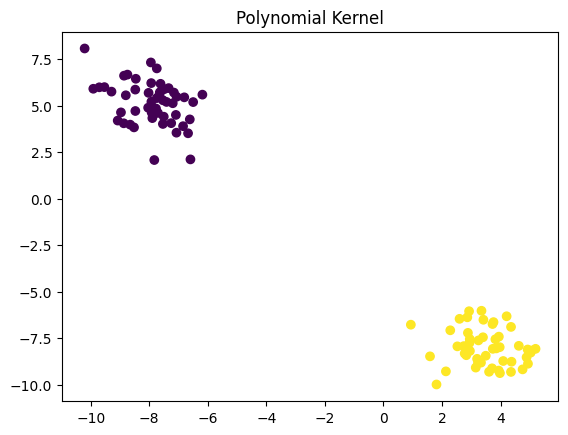

In [4]:
#24
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=100, centers=2)

model = SVC(kernel='poly')
model.fit(X, y)

plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Polynomial Kernel")
plt.show()

In [5]:
#25
from sklearn.datasets import load_breast_cancer
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target)

model = GaussianNB().fit(X_train, y_train)
print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Accuracy: 0.9230769230769231


In [6]:
#26
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

data = fetch_20newsgroups(subset='train')

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data.data)

model = MultinomialNB().fit(X, data.target)
print("Accuracy:", model.score(X, data.target))

Accuracy: 0.9245182959165635


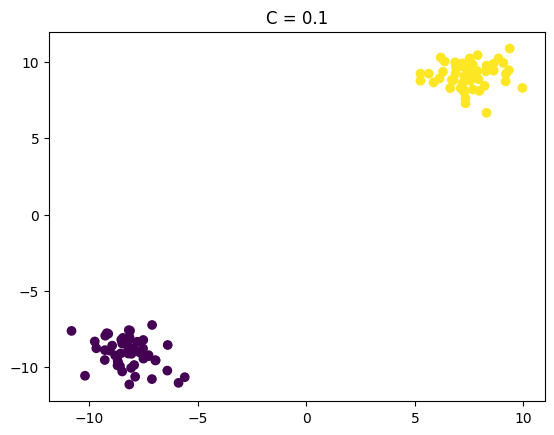

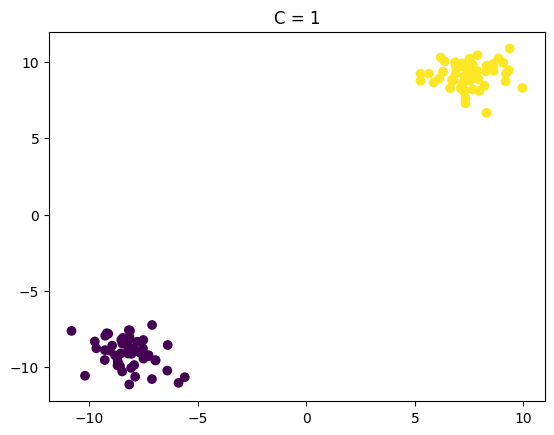

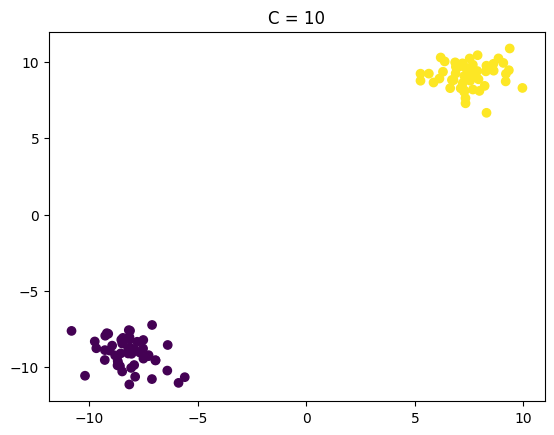

In [7]:
#27
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=100, centers=2)

for c in [0.1, 1, 10]:
    model = SVC(C=c, kernel='linear').fit(X, y)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.title(f"C = {c}")
    plt.show()

In [8]:
#28
from sklearn.naive_bayes import BernoulliNB
from sklearn.datasets import make_classification

X, y = make_classification()

model = BernoulliNB().fit(X, y)
print(model.score(X, y))

0.81


In [9]:
#29
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = SVC().fit(X_train, y_train)
print("Without scaling:", model.score(X_test, y_test))

model.fit(X_train_s, y_train)
print("With scaling:", model.score(X_test_s, y_test))

Without scaling: 0.9736842105263158
With scaling: 0.9736842105263158


In [10]:
#30
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris

data = load_iris()

model = GaussianNB().fit(data.data, data.target)
print(model.predict(data.data[:5]))

[0 0 0 0 0]


In [11]:
#31
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.datasets import load_iris

data = load_iris()

params = {'C':[0.1,1,10], 'kernel':['linear','rbf']}
grid = GridSearchCV(SVC(), params)

grid.fit(data.data, data.target)
print(grid.best_params_)

{'C': 1, 'kernel': 'linear'}


In [12]:
#32
from sklearn.datasets import make_classification
from sklearn.svm import SVC

X, y = make_classification(weights=[0.9,0.1])

model = SVC(class_weight='balanced')
model.fit(X, y)

print("Model trained")

Model trained


In [13]:
#33
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

texts = ["win money", "hello friend", "free prize", "important mail"]
labels = [1,0,1,0]

vec = CountVectorizer()
X = vec.fit_transform(texts)

model = MultinomialNB().fit(X, labels)

print(model.predict(vec.transform(["free money"])))

[1]


In [14]:
#34
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris

data = load_iris()

svm = SVC().fit(data.data, data.target)
nb = GaussianNB().fit(data.data, data.target)

print("SVM:", svm.score(data.data, data.target))
print("NB:", nb.score(data.data, data.target))

SVM: 0.9733333333333334
NB: 0.96


In [15]:
#35
from sklearn.feature_selection import SelectKBest
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris

data = load_iris()

X_new = SelectKBest(k=2).fit_transform(data.data, data.target)

model = GaussianNB().fit(X_new, data.target)
print(model.score(X_new, data.target))

0.96


In [16]:
#36
from sklearn.svm import SVC
from sklearn.datasets import load_wine

data = load_wine()

ovo = SVC(decision_function_shape='ovo').fit(data.data, data.target)
ovr = SVC(decision_function_shape='ovr').fit(data.data, data.target)

print("OvO:", ovo.score(data.data, data.target))
print("OvR:", ovr.score(data.data, data.target))

OvO: 0.7078651685393258
OvR: 0.7078651685393258


In [17]:
#37
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

for k in ['linear','poly','rbf']:
    model = SVC(kernel=k).fit(data.data, data.target)
    print(k, model.score(data.data, data.target))

linear 0.9666080843585237
poly 0.9138840070298769
rbf 0.9226713532513181


In [18]:
#38
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.datasets import load_iris

data = load_iris()

cv = StratifiedKFold(n_splits=5)
scores = cross_val_score(SVC(), data.data, data.target, cv=cv)

print("Average Accuracy:", scores.mean())

Average Accuracy: 0.9666666666666666


In [19]:
#39
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris

data = load_iris()

model = GaussianNB(priors=[0.3,0.3,0.4]).fit(data.data, data.target)
print(model.score(data.data, data.target))

0.96


In [20]:
#40
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
from sklearn.datasets import load_iris

data = load_iris()

rfe = RFE(SVC(kernel='linear'), n_features_to_select=2)
X_rfe = rfe.fit_transform(data.data, data.target)

model = SVC().fit(X_rfe, data.target)
print(model.score(X_rfe, data.target))

0.9533333333333334


In [21]:
#41
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.datasets import load_iris

data = load_iris()

model = SVC().fit(data.data, data.target)
print(classification_report(data.target, model.predict(data.data)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.96      0.96      0.96        50
           2       0.96      0.96      0.96        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



In [22]:
#42
from sklearn.metrics import log_loss
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris

data = load_iris()

model = GaussianNB().fit(data.data, data.target)
probs = model.predict_proba(data.data)

print(log_loss(data.target, probs))

0.1112488207471831


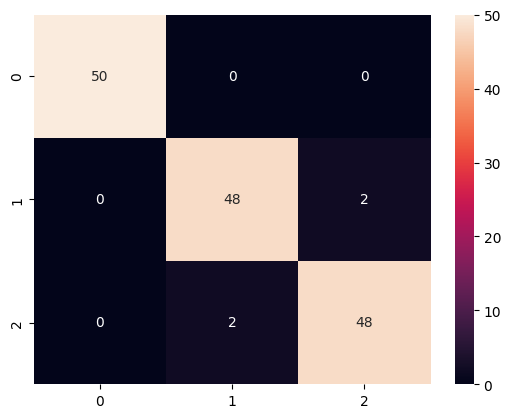

In [23]:
#43
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.svm import SVC

data = load_iris()

model = SVC().fit(data.data, data.target)
cm = confusion_matrix(data.target, model.predict(data.data))

sns.heatmap(cm, annot=True)
plt.show()

In [24]:
#44
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
import numpy as np

X = np.random.rand(100,1)
y = 3*X.flatten()

model = SVR().fit(X, y)
pred = model.predict(X)

print(mean_absolute_error(y, pred))

0.040809868705486994


In [25]:
#45
from sklearn.metrics import roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

model = GaussianNB().fit(data.data, data.target)
probs = model.predict_proba(data.data)[:,1]

print(roc_auc_score(data.target, probs))

0.9890333491887321


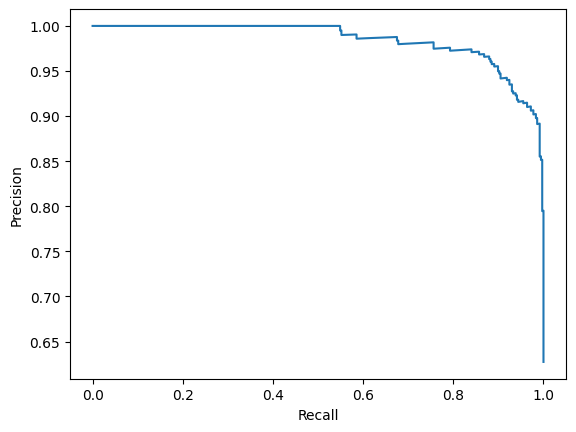

In [26]:
#46
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

model = SVC(probability=True).fit(data.data, data.target)
probs = model.predict_proba(data.data)[:,1]

precision, recall, _ = precision_recall_curve(data.target, probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()